In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset=pd.read_csv('household_power_consumption.csv')

In [3]:
dataset.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [4]:
dataset.shape

(1048575, 9)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


In [6]:
dataset.describe()

,Sub_metering_3
count,1.044506e+06
mean,5.933837e+00
std,8.210398e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [7]:
dataset=dataset.drop_duplicates()

In [8]:
dataset.shape

(1048575, 9)

### Parse and resample the time series data

In [9]:
dataset['Datetime'] = pd.to_datetime(dataset['Date']+' '+ dataset['Time'])
dataset['Global_active_power']=dataset['Global_active_power'].replace("?" ,"")
dataset['Global_reactive_power']=dataset['Global_reactive_power'].replace("?" ,"")
dataset['Voltage']=dataset['Voltage'].replace("?" ,"")
dataset['Global_intensity']=dataset['Global_intensity'].replace("?" ,"")
dataset['Sub_metering_1']=dataset['Sub_metering_1'].replace("?" ,"")
dataset['Sub_metering_2']=dataset['Sub_metering_2'].replace("?" ,"")
dataset['Sub_metering_3']=dataset['Sub_metering_3'].replace("?" ,"")

In [10]:
dataset.drop(['Date' , 'Time'] , axis=1 , inplace=True)

In [11]:
for i in dataset.select_dtypes('object'):
    dataset[i]=pd.to_numeric(dataset[i])

In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Global_active_power    1044506 non-null  float64       
 1   Global_reactive_power  1044506 non-null  float64       
 2   Voltage                1044506 non-null  float64       
 3   Global_intensity       1044506 non-null  float64       
 4   Sub_metering_1         1044506 non-null  float64       
 5   Sub_metering_2         1044506 non-null  float64       
 6   Sub_metering_3         1044506 non-null  float64       
 7   Datetime               1048575 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 64.0 MB


###  Engineer time-based features (e.g., hour of day, weekday/weekend)

In [13]:
dataset['Hour'] = dataset['Datetime'].dt.hour
dataset['DayOfWeek'] = dataset['Datetime'].dt.dayofweek
dataset['IsWeekend'] = dataset['Datetime'].dt.dayofweek.isin([5, 6]).astype(int)

In [14]:
dataset.drop('Datetime' , axis=1 , inplace=True)

In [15]:
dataset.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,DayOfWeek,IsWeekend
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,5,1
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,5,1
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,5,1
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,5,1
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,5,1


### Data Visualization

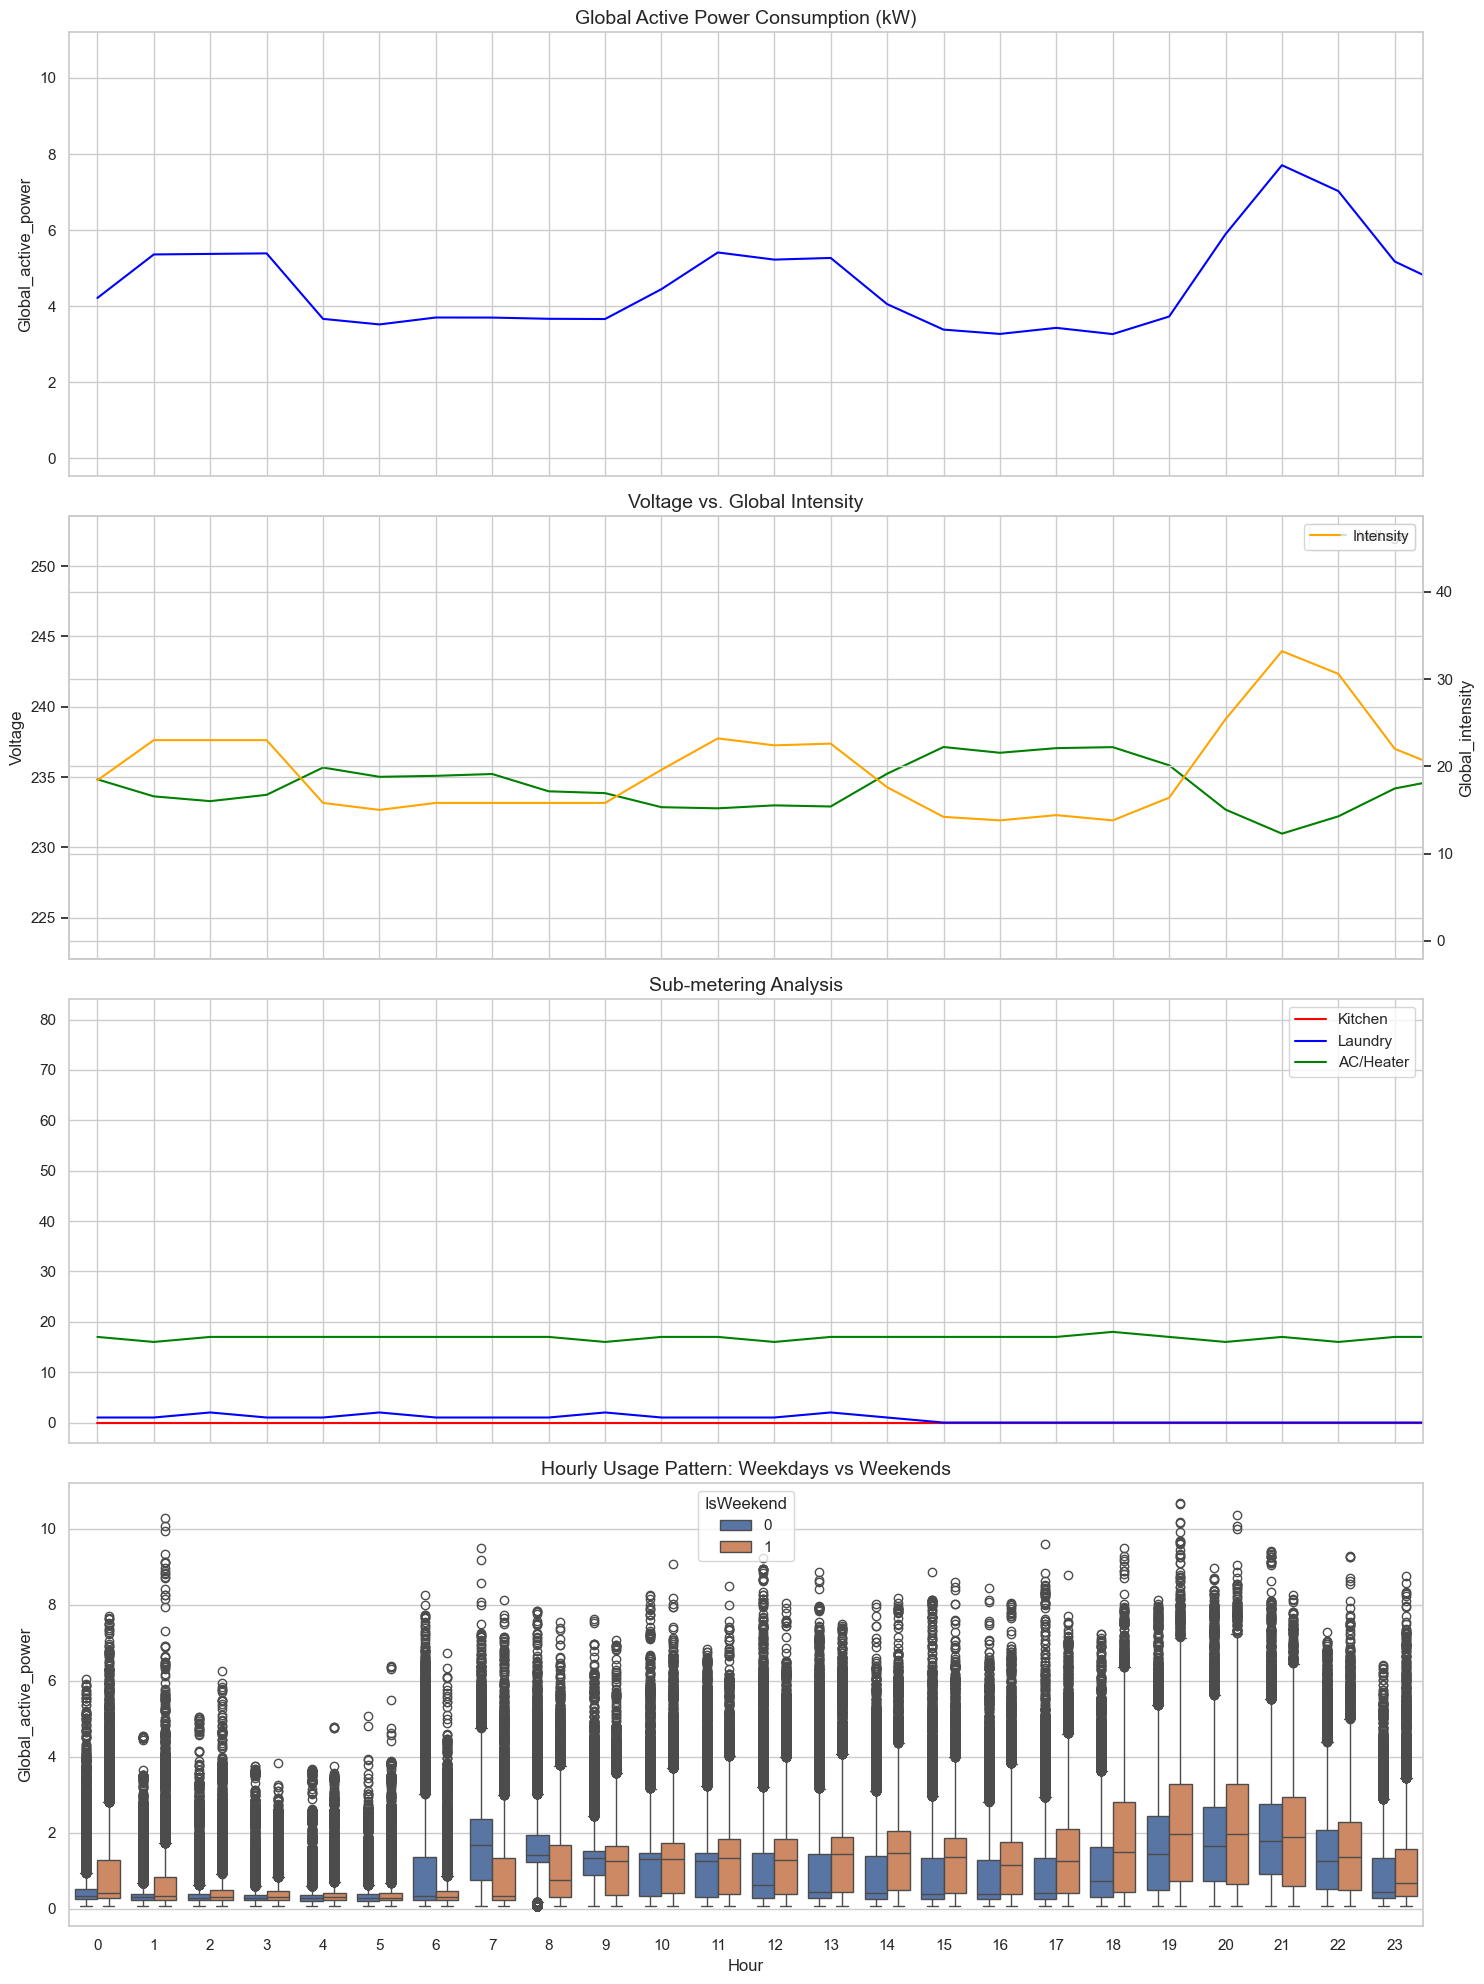

In [16]:
# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with 4 rows of subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20), sharex=True)

# 1. Global Active Power (Primary Target)
sns.lineplot(data=dataset, x=dataset.index, y='Global_active_power', ax=axes[0], color='blue')
axes[0].set_title('Global Active Power Consumption (kW)', fontsize=14)

# 2. Voltage & Intensity (Electrical Health)
sns.lineplot(data=dataset, x=dataset.index, y='Voltage', ax=axes[1], color='green', label='Voltage')
ax2 = axes[1].twinx() # Secondary axis for Intensity
sns.lineplot(data=dataset, x=dataset.index, y='Global_intensity', ax=ax2, color='orange', label='Intensity')
axes[1].set_title('Voltage vs. Global Intensity', fontsize=14)

# 3. Sub-metering Breakdown (Where is the power going?)
axes[2].plot(dataset.index, dataset['Sub_metering_1'], label='Kitchen', color='red')
axes[2].plot(dataset.index, dataset['Sub_metering_2'], label='Laundry', color='blue')
axes[2].plot(dataset.index, dataset['Sub_metering_3'], label='AC/Heater', color='green')
axes[2].set_title('Sub-metering Analysis', fontsize=14)
axes[2].legend()

# 4. Weekend vs Weekday Patterns (Time Features)
sns.boxplot(data=dataset, x='Hour', y='Global_active_power', hue='IsWeekend', ax=axes[3])
axes[3].set_title('Hourly Usage Pattern: Weekdays vs Weekends', fontsize=14)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

### Outliers 

In [17]:

Q1 = dataset['Global_active_power'].quantile(0.25)
Q3 = dataset['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1


upper_bound = Q3 + 1.5 * IQR

# Create an 'Is_Outlier' column
# Create a NEW column named 'Is_Outlier'
dataset['Is_Outlier'] = (dataset['Global_active_power'] > upper_bound).astype(int)

print(f"Total Outliers detected: {dataset['Global_active_power'].sum()}")

Total Outliers detected: 1157523.814


In [18]:
def detect_hourly_outliers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return group > upper

# Apply the detection per Hour group
dataset['Is_Hourly_Outlier'] = dataset.groupby('Hour')['Global_active_power'].transform(detect_hourly_outliers)

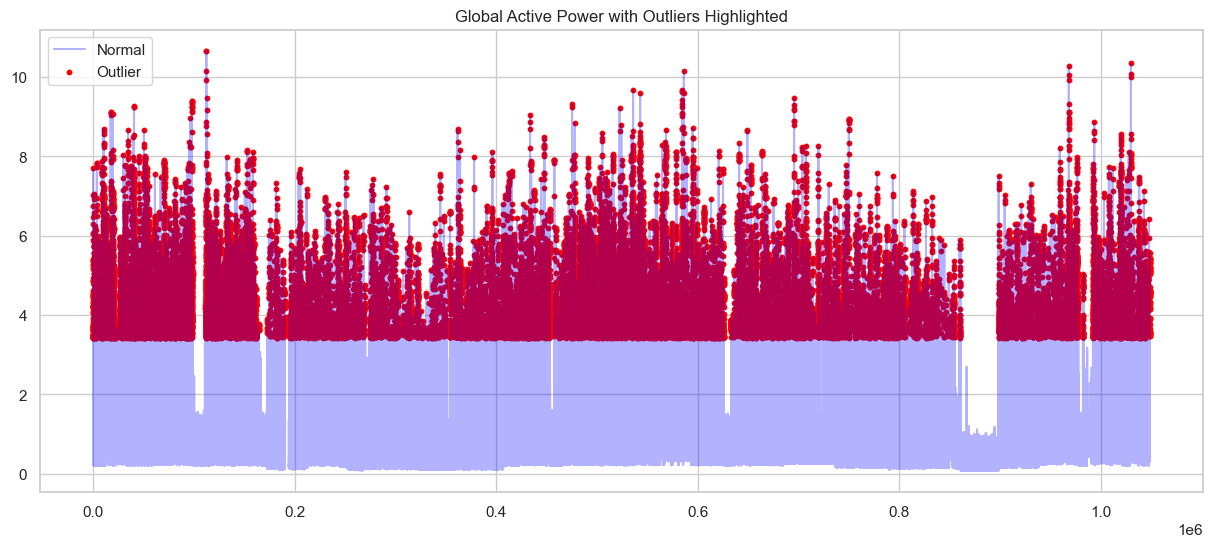

In [19]:
plt.figure(figsize=(15, 6))
# Plot the regular data
plt.plot(dataset.index, dataset['Global_active_power'], color='blue', alpha=0.3, label='Normal')
# Overlap the outliers in red
outliers = dataset[dataset['Is_Outlier'] == 1]
plt.scatter(outliers.index, outliers['Global_active_power'], color='red', s=10, label='Outlier')

plt.title('Global Active Power with Outliers Highlighted')
plt.legend()
plt.show()

### Create Target Value to Predict

In [20]:
dataset['Target_Future_Power'] = dataset['Global_active_power'].shift(-1)
dataset = dataset.dropna()
dataset.drop('Global_active_power' , axis=1 , inplace=True)

### Compare performance of ARIMA, Prophet, and XGBoost models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.23, random_state=42)

In [ ]:
Xgb=XGBRFRegressor()

In [ ]:
Xgb.fit(X_train,y_train)

In [ ]:
y_pred=Xgb.predict(X_test)

In [ ]:
Xgb.score(X_test,y_test)*100

In [ ]:
print(mean_absolute_error(y_test , y_pred))
print(mean_squared_error(y_test , y_pred))
print(root_mean_squared_error(y_test , y_pred))